In [7]:
# confusion matrix
# 실제 정답 / 정답 맞힌경우 (TP)
# 실제 오답 / 오답 맞힌경우 (TN)
# 실제 오답 / 정답 틀린경우 (FP)
# 실제 정답 / 오답 틀린경우 (FN)

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
- PRECISION(정밀도) : 모델이 긍정이라고 예측한 것들중에서 실제 긍정인 비율 : 틀리지 않는것이 중요(스펨메일 분류)
$$\text{Precision} = \frac{TP}{TP + FP}$$
- Recall(재현율) : 실제 정답중에서 모델이 정답이라고 찾아낸 비율(암 진단)
$$\text{Recall} = \frac{TP}{TP + FN}$$
- F1-SCORE : 정밀도 재현율은 트레이드오프 관계가 있는경우가 많음 : 조화평균을 사용한다
$$F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

($F_\beta$) : 재현율(Recall)을 정밀도(Precison) 보다 얼마나 더 중요하게 여기는지 나타내는 계수

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# 한글깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


In [13]:
y_true = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])
# 모델이 1이라고 예측할 확률(0.0~1.0)
y_scores = np.array([0.1, 0.4, 0.35, 0.8, 0.9, 0.2, 0.3, 0.6, 0.7, 0.2])
# 임계값 설정
threshold = 0.5
# 예측 결과 계산
y_pred = (y_scores >= threshold).astype(int)
conf_matrix = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel().tolist()

conf_matrix, tn, fp, fn, tp

(array([[3, 2],
        [3, 2]], dtype=int64),
 3,
 2,
 3,
 2)

In [6]:
# 정밀도
precision_score_ = precision_score(y_true, y_pred)
print(precision_score_, 3/6)
# 재현율
recall_score_ = recall_score(y_true, y_pred)
print(recall_score_, 2/5)

0.6 0.5
0.6 0.4


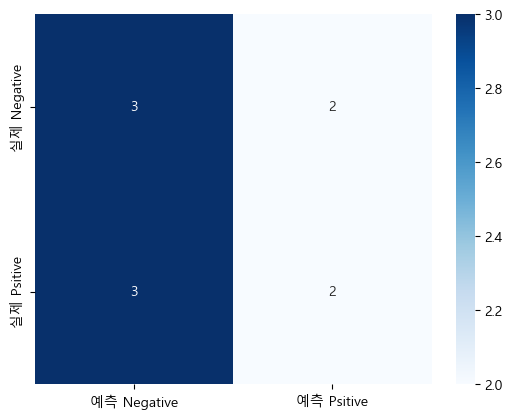

In [14]:
conf_matrix = confusion_matrix(y_true, y_pred)
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='Blues',
            xticklabels= ['예측 Negative','예측 Psitive'],
            yticklabels= ['실제 Negative','실제 Psitive'],            
            )
plt.show()

In [15]:
y_true = np.array([0, 0, 0, 1, 1, 0, 0, 1, 1, 0])
x_prob = np.array([0.1, 0.4, 0.35, 0.8, 0.9, 0.2, 0.3, 0.6, 0.7, 0.2])
threshold = 0.8  # 확실한 경우만 1로 보겠음... 
# 정밀도, 재현율
y_predict = (x_prob>=threshold).astype(int)
print( precision_score(y_true,y_predict),
        recall_score(y_true,y_predict)
)

threshold = 0.3  # 대략적으로 비슷하면 1로 보겠음...
# 정밀도, 재현율
y_predict = (x_prob>=threshold).astype(int)
print( precision_score(y_true,y_predict),
        recall_score(y_true,y_predict)
)

1.0 0.5
0.5714285714285714 1.0


실제정답 [0 0 0 1 1 0 0 1 1 0]
[0.4        0.44444444 0.57142857 0.66666667 0.8        1.
 1.         1.         1.         1.        ]
 [1.   1.   1.   1.   1.   1.   0.75 0.5  0.25 0.  ] 
 [0.1  0.2  0.3  0.35 0.4  0.6  0.7  0.8  0.9 ]


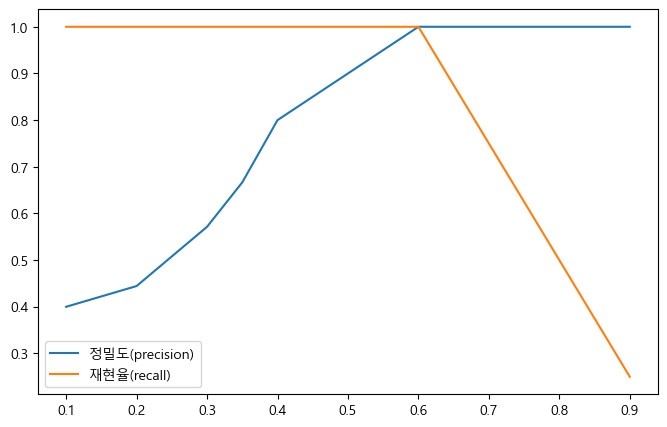

In [11]:
from sklearn.metrics import precision_recall_curve
precision , recall, threshold = precision_recall_curve(y_true,x_prob)
print('실제정답',y_true)
print(f'{precision}\n {recall} \n {threshold}')
plt.figure(figsize=(8,5))
plt.plot(threshold, precision[:-1],label='정밀도(precision)')
plt.plot(threshold, recall[:-1],label='재현율(recall)')
plt.legend()
plt.show()

In [ ]:
# ROC : ROC Curve
# -> 기준선을 바꿔가면서 정답을 맞추는 비율 TPR 재현율 (y축)
# -> 오답을 정답이라고 판단한 비율 FPR (x축)
# AUC : Area Under the Curve


[0.         0.16666667 0.16666667 0.66666667 1.        ] 
 [0.   0.25 1.   1.   1.  ] 
 [inf 0.9 0.6 0.3 0.2]
AUC(곡선아래 면적) 0.8542


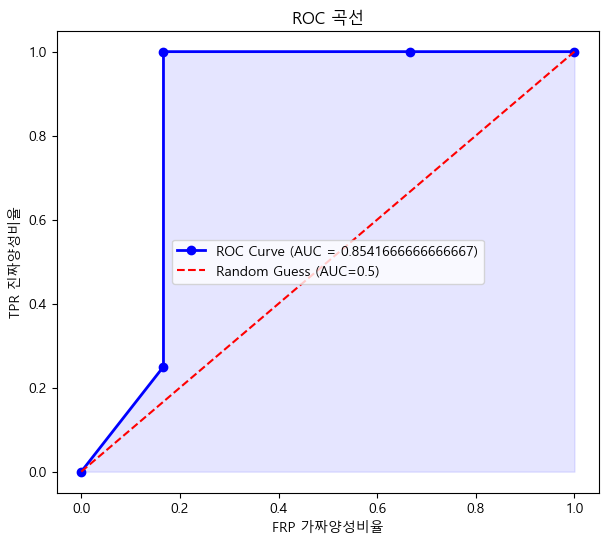

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

y_true = np.array([0, 0, 0, 1, 1, 0, 0, 1, 1, 0])
x_prob = np.array([0.9, 0.4, 0.35, 0.8, 0.9, 0.2, 0.3, 0.6, 0.7, 0.2])

roc_curve(y_true,x_prob)
fpr, tpr, threshold = roc_curve(y_true,x_prob)
print(fpr,'\n', tpr,'\n', threshold)
roc_acu = roc_auc_score(y_true,x_prob)
print(f'AUC(곡선아래 면적) {roc_acu:.4f}')

# ROC 곡선
plt.figure(figsize=(7,6))
plt.plot(fpr,tpr,color='blue',linewidth=2,marker='o', label=f'ROC Curve (AUC = {roc_acu})') 
plt.plot([0,1],[0,1] ,color='red', linestyle='--' , label = 'Random Guess (AUC=0.5)')
plt.fill_between(fpr ,tpr, color='blue', alpha=0.1)  # 곡선아래 면적
plt.title('ROC 곡선')
plt.xlabel('FRP 가짜양성비율')
plt.ylabel('TPR 진짜양성비율')
plt.legend()
plt.show()


In [15]:
# 암 진단처럼 재현율이 우선인 모델 생성
# -> 1. 결과값에 threshold를 낮게 부여 / recall 값을 올리는 threshold를 찾는방법
# -> 2. 학습할 때 암환자를 놓치는 경우 패널티 강하게 부여 / 손실함수 수정, BCEwithLogitLoss의 파라메터 수정

from sklearn.datasets import load_breast_cancer
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam

# 한글깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [16]:
from collections import Counter

X, y = load_breast_cancer(return_X_y=True)
y = 1 - y   # 악성을 1, 양성(정상)을 0
print(Counter(y))

X_trian, X_test, y_train, y_test = train_test_split(X, y, stratify=y, shuffle=True, random_state=42, test_size=0.2)

scaler = StandardScaler()
X_trian = scaler.fit_transform(X_trian)
X_test = scaler.transform(X_test)


X_trian_t = torch.FloatTensor(X_trian)
y_trian_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

Counter({0: 357, 1: 212})


In [21]:
# 신경망
# 은닉 (x_dim, 32)
# 은닉 (32, 16)
# 은닉 (16, 1)
# 활성함수 ReLU

class AnnModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
        nn.Linear(input_dim, 32),
        nn.ReLU(),
        nn.Linear(32,16),
        nn.ReLU(),
        nn.Linear(16,1))
    def forward(self, x):
        return self.network(x)
    
def print_metrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    ps = precision_score(y_true, y_pred)
    rs = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f'confusion_matrix {cm}')
    print(f'precision_score {ps}')
    print(f'recall_score {rs}')
    print(f'f1_score {f1}')


In [23]:
torch.manual_seed(42)
model = AnnModel(X_trian_t.shape[-1])
criterion = nn.BCEWithLogitsLoss()
optimizer = Adam(model.parameters(), lr=0.01)
epochs = 100
for epoch in range(epochs):
    optimizer.zero_grad()
    y_predict = model(X_trian_t).squeeze(1)
    loss = criterion(y_trian_t, y_predict)
    loss.backward()
    optimizer.step()

with torch.no_grad():
    logits = model(X_test_t)
    props = torch.sigmoid(logits).numpy()

threshold = 0.001
preds_05 = (props >= threshold).astype(int)
print_metrix(y_test, preds_05)


confusion_matrix [[ 0 72]
 [ 0 42]]
precision_score 0.3684210526315789
recall_score 1.0
f1_score 0.5384615384615384
